# 03 -- Complex numbers and phasors

| question | answer |
|---|---|
| What physics problem? | An oscillation has an amplitude and a phase. |
| What mathematics? | The complex plane, Euler's formula, polar form, roots of unity. |
| What algorithm? | Represent a sinusoid as a rotating phasor; add oscillations by adding phasors. |
| What software? | NumPy complex arrays; SymPy for Euler's identity. |
| What experiment? | A lock-in amplifier measures amplitude and phase (I and Q). |
| What engineering application? | A receiver stores complex baseband samples as interleaved I/Q. |

This notebook follows the repository template: English explanation, mathematical derivation,
dimensions and SI units, SymPy derivation, NumPy implementation, Pandas tables, Matplotlib plots,
optional PyTorch, exercises, and engineering applications. It reuses the `physkit` package and the
results of earlier chapters.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
import physkit
from physkit import constants as C, units as U, linalg as la
from physkit.plotting import use_style
use_style()
torch = physkit.optional_torch()            # None if PyTorch is unavailable; NumPy stays authoritative
sp.init_printing()
print("physkit", physkit.__version__, "| numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

physkit 0.1.0 | numpy 2.4.6 | torch: absent (optional)


## English explanation

A steady oscillation $A\cos(\omega t+\phi)$ is fixed by two numbers, an amplitude $A$ and a
phase $\phi$. A complex number $z=A e^{i\phi}$ packages both, and multiplying by $e^{i\omega t}$
makes it rotate. Because addition of complex numbers is componentwise, superposing oscillations of
the same frequency reduces to adding **phasors** -- arrows in the complex plane. This is why AC
circuits, waves, and interference are all done with complex arithmetic.

Subject-verb-object: the phasor encodes amplitude and phase; the exponential rotates it; the sum
interferes.

## Mathematical derivation

Euler's formula $e^{i\theta}=\cos\theta+i\sin\theta$ follows from matching the Taylor series
of both sides. Then $A\cos(\omega t+\phi)=\mathrm{Re}\{A e^{i\phi}e^{i\omega t}\}$, so the complex
amplitude (phasor) is $\tilde A=A e^{i\phi}$. The modulus squared $|z|^2=z\bar z=A^2$ is the
intensity, and the $n$-th roots of unity $e^{2\pi i k/n}$ are the equally spaced points that solve
$z^n=1$.

## Dimensions and SI units

A phasor inherits the unit of the quantity it represents: a voltage phasor is in volts, its
modulus is a voltage, and $|z|^2$ carries $\mathrm{V}^2$ (proportional to power into a fixed
resistance). The phase is a pure number (radians).

In [2]:
V = U.Quantity(5.0, U.VOLTAGE)          # amplitude of a voltage phasor
power_like = V * V                       # |V|^2 ~ V^2
print("phasor amplitude dim:", V.dim, "| |V|^2 dim:", power_like.dim)
assert power_like.dim == U.VOLTAGE**2

phasor amplitude dim: L^2 M^1 T^-3 I^-1 | |V|^2 dim: L^4 M^2 T^-6 I^-2


## SymPy derivation

In [3]:
theta = sp.symbols('theta', real=True)
assert sp.simplify(sp.exp(sp.I*theta) - (sp.cos(theta) + sp.I*sp.sin(theta))) == 0
print("Euler: e^{i theta} =", sp.cos(theta) + sp.I*sp.sin(theta))
# A cos(w t + phi) = Re{ A e^{i phi} e^{i w t} }
A, w, t, phi = sp.symbols('A omega t phi', real=True)
lhs = A*sp.cos(w*t + phi)
rhs = sp.re(A*sp.exp(sp.I*phi)*sp.exp(sp.I*w*t))
assert sp.simplify(lhs - rhs) == 0
print("A cos(w t + phi) = Re{ phasor * e^{i w t} } verified")

Euler: e^{i theta} = I*sin(theta) + cos(theta)
A cos(w t + phi) = Re{ phasor * e^{i w t} } verified


## NumPy implementation

Add two phasors of the same frequency and read off the resultant amplitude and phase -- the
core of interference and AC superposition.

In [4]:
p1 = 3 * np.exp(1j*np.deg2rad(0))
p2 = 2 * np.exp(1j*np.deg2rad(90))
s = p1 + p2
print(f"resultant amplitude = {abs(s):.4f}, phase = {np.rad2deg(np.angle(s)):.2f} deg")
print("check: sqrt(3^2+2^2) =", np.hypot(3, 2))
# n-th roots of unity
n = 6
roots = np.exp(2j*np.pi*np.arange(n)/n)
print("6th roots of unity sum to ~0:", np.isclose(roots.sum(), 0))

resultant amplitude = 3.6056, phase = 33.69 deg
check: sqrt(3^2+2^2) = 3.605551275463989
6th roots of unity sum to ~0: True


## Pandas tables

In [5]:
rows = []
for label, z in [("3 @ 0deg", p1), ("2 @ 90deg", p2), ("sum", s)]:
    rows.append({"phasor": label, "Re": round(z.real,3), "Im": round(z.imag,3),
                 "amplitude": round(abs(z),3), "phase_deg": round(np.rad2deg(np.angle(z)),1)})
print(pd.DataFrame(rows).to_string(index=False))

   phasor  Re  Im  amplitude  phase_deg
 3 @ 0deg 3.0 0.0      3.000        0.0
2 @ 90deg 0.0 2.0      2.000       90.0
      sum 3.0 2.0      3.606       33.7


## Matplotlib plots

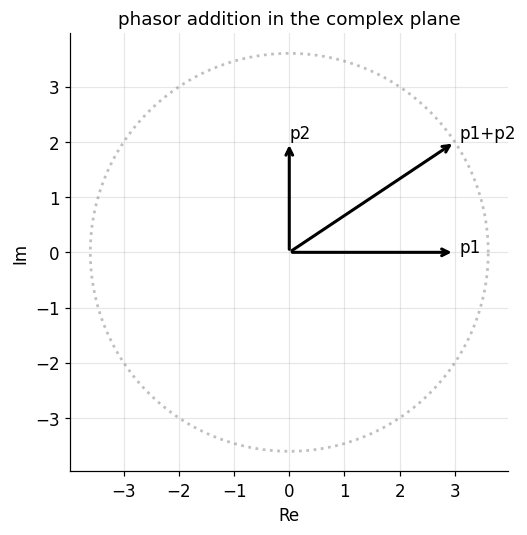

In [6]:
fig, ax = plt.subplots(figsize=(5.2, 5))
for z, lab in [(p1, "p1"), (p2, "p2"), (s, "p1+p2")]:
    ax.annotate("", xy=(z.real, z.imag), xytext=(0,0), arrowprops=dict(arrowstyle="->", lw=2))
    ax.text(z.real*1.03, z.imag*1.03, lab)
th = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(th)*abs(s), np.sin(th)*abs(s), ":", color="gray", alpha=0.5)
ax.set_aspect("equal"); ax.set_xlabel("Re"); ax.set_ylabel("Im")
ax.set_title("phasor addition in the complex plane"); plt.tight_layout(); plt.show()

## PyTorch (optional)

In [7]:
if torch is not None:
    z = torch.tensor([p1, p2], dtype=torch.complex128)
    print("torch phasor sum amplitude:", float(torch.abs(z.sum())))
else:
    print("PyTorch absent -- NumPy phasor sum above is authoritative.")

PyTorch absent -- NumPy phasor sum above is authoritative.


## Exercises

1. Show $A\cos(\omega t)+B\sin(\omega t)=R\cos(\omega t-\varphi)$ with
   $R=\sqrt{A^2+B^2}$, $\varphi=\operatorname{atan2}(B,A)$, by phasor addition.
2. Plot the $n$-th roots of unity for $n=3,4,5$ and confirm they sum to zero.
3. Two waves of equal amplitude and a phase difference $\delta$ interfere; derive the resultant
   intensity $I\propto\cos^2(\delta/2)$ from the phasor sum.

## Engineering applications

A coherent **receiver** mixes the signal down to complex **baseband**, storing in-phase (I) and
quadrature (Q) samples -- literally the real and imaginary parts of a phasor. **DSP** rotates and
filters these complex samples; the **FFT** in later chapters is complex throughout. A lock-in
**detector** reports amplitude and phase, the polar form of $z$. Complex arithmetic is the native
language of every phase-sensitive instrument.

Summary (subject-verb-object): the phasor stores amplitude and phase; Euler's formula rotates it;
the receiver samples I and Q; the DSP processes the complex stream.